# Task 3 — Simple Linear Regression with Gradient Descent

Dataset `Salary Data.csv`
1. **scikit-learn `LinearRegression`**
2. **Gradient Descent from scratch**


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv('Salary Data.csv')
print("Dataset Head:")
print(df.head())


Dataset Head:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


## 1. Part A — Fit the Model Using scikit-learn

In [21]:
X = df[['YearsExperience']]
y = df['Salary']

model = LinearRegression()
model.fit(X, y)

print("Sklearn Slope (m):", model.coef_[0])
print("Sklearn Intercept (c):", model.intercept_)

Sklearn Slope (m): 9449.962321455074
Sklearn Intercept (c): 25792.20019866871


## 2. Part B — Implement Gradient Descent by Hand

In [31]:
X = df['YearsExperience'].values.astype(float)
Y = df['Salary'].values.astype(float)
n = len(X)

m, c = 0.0, 0.0 #parameters
lr = 0.005 #Rate of learning
epochs = 50000 #number of itertion

loss_history = []

for i in range(epochs):
    Y_pred = m * X + c
    error = Y_pred - Y
    
    loss = (1/n) * np.sum(error ** 2)
    loss_history.append(loss)
    
    dm = (2/n) * np.sum(error * X)
    dc = (2/n) * np.sum(error)
    
    m = m - lr * dm
    c = c - lr * dc
    
    if i % 10000 == 0:
        print("epoch", i, "loss:", round(loss, 2), "m:", round(m, 3), "c:", round(c, 3))

print("Final Gradient Descent parameters -> m:", round(m, 4), "c:", round(c, 4))


epoch 0 loss: 6502955270.73 m: 4773.987 c: 760.03
epoch 10000 loss: 31270951.72 m: 9449.962 c: 25792.2
epoch 20000 loss: 31270951.72 m: 9449.962 c: 25792.2
epoch 30000 loss: 31270951.72 m: 9449.962 c: 25792.2
epoch 40000 loss: 31270951.72 m: 9449.962 c: 25792.2
Final Gradient Descent parameters -> m: 9449.9623 c: 25792.2002


epoch 10000 loss: 31270951.72 m: 9449.962 c: 25792.2


epoch 20000 loss: 31270951.72 m: 9449.962 c: 25792.2


epoch 30000 loss: 31270951.72 m: 9449.962 c: 25792.2


epoch 40000 loss: 31270951.72 m: 9449.962 c: 25792.2


Final Gradient Descent parameters -> m: 9449.9623 c: 25792.2002


## 3. Plot Fitted Lines vs Actual Data

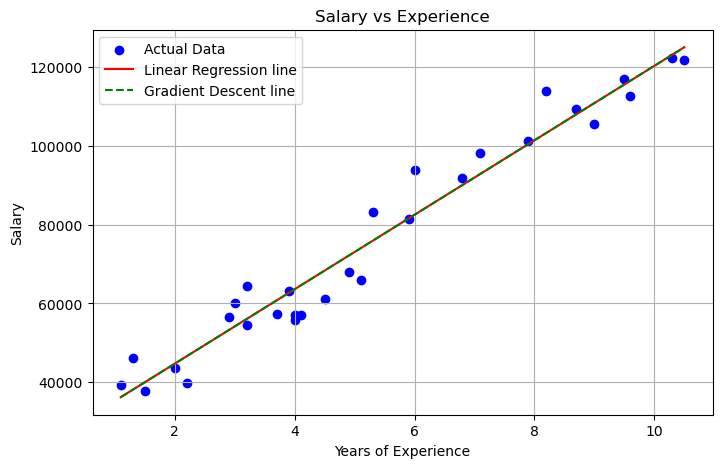

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='blue', label='Actual Data')
plt.plot(df['YearsExperience'], model.predict(df[['YearsExperience']]), color='red', label='Linear Regression line')
plt.plot(df['YearsExperience'], m * df['YearsExperience'] + c, color='green', linestyle='--', label='Gradient Descent line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.legend()
plt.grid(True)
plt.show()


## 4. Comparison: Scikit-Learn vs. Gradient Descent

In [29]:
comparison = pd.DataFrame({
    'Parameter': ['Slope (m)', 'Intercept (c)'],
    'scikit-learn': [model.coef_[0], model.intercept_],
    'Gradient Descent': [m, c]
})

print(comparison)

       Parameter  scikit-learn  Gradient Descent
0      Slope (m)   9449.962321       9449.962321
1  Intercept (c)  25792.200199      25792.200199
